<a href="https://colab.research.google.com/github/replysantosh-lang/ECARDeepLearning/blob/main/Basic_Convolutional_Network_1_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

When you download or use it in Kaggle/Colab, you will see:
seg_train/
seg_test/
seg_pred/   (sometimes present)

**1. Training Data → seg_train**
This is your main dataset used to train the model.

Contains images in 6 categories:

i) buildings
ii) forest
iii) glacier
iv) mountain
v) sea
vi) street

Folder structure:
seg_train/
    buildings/
    forest/
    glacier/
    mountain/
    sea/
    street/

Each folder contains images of that class.

Purpose:
Used to teach the model
Model learns patterns (edges, shapes, textures)

**2. Test Data → seg_test**

This is NOT validation, but many students confuse it.

seg_test/
    buildings/
    forest/
    glacier/
    mountain/
    sea/
    street/

Purpose:
Used after training is complete
Measures final performance (accuracy)

**3. Validation Data → ❗ NOT PROVIDED DIRECTLY**

Important point 👇
👉 The dataset does NOT have a separate validation folder

So you must create validation data manually from seg_train

How to Create Validation Split

Typically:

80% → Training
20% → Validation

**What This Code Does (Simple Understanding)**

Reads images from:

seg_train/

   buildings/

   forest/

   glacier/

   mountain/

   sea/

   street/

Automatically:

Assigns labels (one-hot encoding)

Resizes images to 150×150

Splits into:

80% training

20% validation

In [10]:
# 1. Import Libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
# 2. Set Dataset Path
train_dir="/content/drive/MyDrive/Intel_Image_Classification_Dataset/seg_train/"
test_dir="/content/drive/MyDrive/Intel_Image_Classification_Dataset/seg_test/"
validation_dir="/content/drive/MyDrive/Intel_Image_Classification_Dataset/seg_validate"



In [13]:
# 3. Data Preprocessing (Train + Validation Split)

train_datagen = ImageDataGenerator(
rescale=1./255,
rotation_range=40,
width_shift_range=0.2,
height_shift_range=0.2,
shear_range=0.2,
zoom_range=0.2,
horizontal_flip=True,)

#Resize all images to 150x150
train_generator = train_datagen.flow_from_directory(
    train_dir,target_size=(150, 150),batch_size=32, class_mode='categorical')

#Validation Data Set should not be augmented
test_datagen = ImageDataGenerator(rescale=1./255)

#Resize all images to 150x150
validation_generator = test_datagen.flow_from_directory(
    validation_dir,target_size=(150, 150),batch_size=32, class_mode='categorical')

Found 11229 images belonging to 6 classes.
Found 2805 images belonging to 6 classes.


**# 3. Data Preprocessing (Train + Validation Split)**

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)
#OUTPUT
#Found 8986 images belonging to 6 classes.
#Found 2243 images belonging to 6 classes.

In [14]:
#4. Load Test Data
test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
     shuffle=False
)

Found 3000 images belonging to 6 classes.


In [15]:
#5. Build CNN Model

model = models.Sequential()

# Block 1
# Conv2D(32, (3,3)) + MaxPooling

# Extracts low-level features
# Learns:
#       edges
#       corners
#       textures

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)))
model.add(layers.MaxPooling2D(2,2))
# Block 2
# Conv2D(64, (3,3)) + MaxPooling
# Extracts mid-level features
# Learns:
#       shapes
#       patterns
#       object parts
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

# Block 3
# Conv2D(128, (3,3)) + MaxPooling
# Extracts high-level features
#Learns:
#     full objects
#     class-specific patterns
model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

#Extra Code
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Flatten
# Flatten()
# Converts 2D feature maps → 1D vector
# Required before Dense layer
model.add(layers.Flatten())

# Dense Layers (Dense + Dropout)
# Dense(128, relu)
# Dropout(0.5)
# Fully connected layer → learns classification logic
# Dropout:
# Prevents overfitting
# Randomly drops 50% neurons during training
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))

# Output Layer (6 classes)
# Dense(6, softmax)
# 6 neurons → 6 classes
# Softmax → probability distribution

model.add(layers.Dense(6, activation='softmax'))

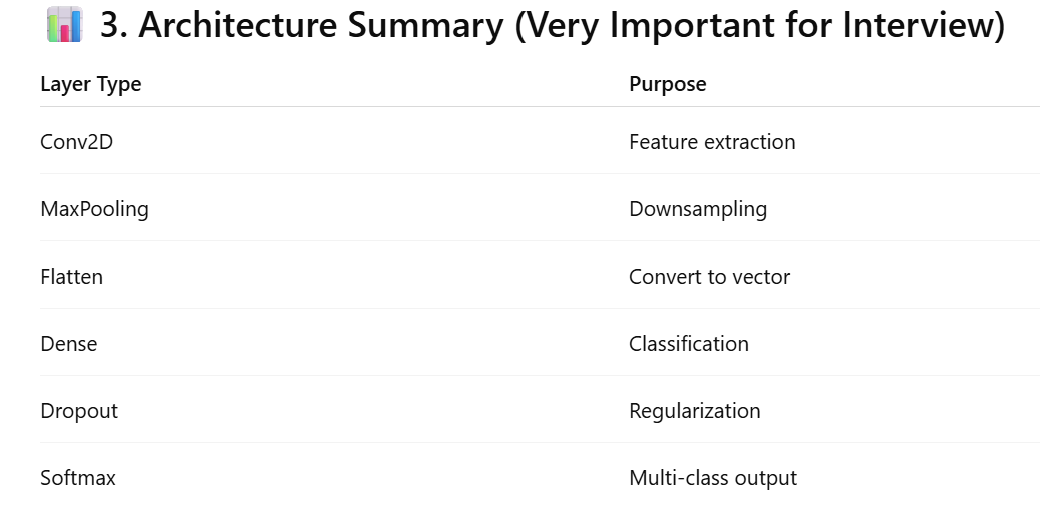

**4. Model Flow (Super Important Concept)**

Input Image (150x150x3)
       ↓

Conv → Pool → Conv → Pool → Conv → Pool
        ↓

Flatten
        ↓

Dense + Dropout
        ↓

Softmax (6 classes)

In [16]:
#6. Compile Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# 7. Train Model
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 771s 2s/step - accuracy: 0.4750 - loss: 1.2925 - val_accuracy: 0.5950 - val_loss: 0.9822
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 752s 2s/step - accuracy: 0.5581 - loss: 1.1123 - val_accuracy: 0.6164 - val_loss: 0.9867
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 760s 2s/step - accuracy: 0.6130 - loss: 1.0158 - val_accuracy: 0.7016 - val_loss: 0.8261
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 761s 2s/step - accuracy: 0.6598 - loss: 0.9061 - val_accuracy: 0.7241 - val_loss: 0.7398
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 767s 2s/step - accuracy: 0.6744 - loss: 0.8634 - val_accuracy: 0.7373 - val_loss: 0.7283
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 740s 2s/step - accuracy: 0.6979 - loss: 0.8324 - val_accuracy: 0.7786 - val_loss: 0.6156
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 779s 2s/step - accuracy: 0.7057 - loss: 0.7982 - val_accuracy: 0.7775 - val_loss: 0.6203
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 767s 2s/step - accuracy: 0.7236 - loss: 0.7666 - val_accu

In [ ]:
# 8. Evaluate on Test Data
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

In [ ]:
# 9. Accuracy & Loss Graphs
# Accuracy Plot
plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

# Loss Plot
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Graph")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

What you just built:
CNN with 3 convolution layers
ReLU activation
MaxPooling
Dropout (prevents overfitting)
Softmax output (6 classes)

Tips to Improve Accuracy

You can upgrade this model easily:

👉 Add data augmentation

ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

#👉 Increase epochs (20–30)
#👉 Use pretrained models (Transfer Learning like ResNet)

Final Understanding

Pipeline you implemented:

Dataset → Train Split → CNN → Validation → Test → Graphs